Device: cuda
Languages: ['assamese', 'bengali', 'bodo', 'dogri', 'gujarati', 'hindi', 'kannada', 'kashmiri', 'konkani', 'maithili', 'malayalam', 'manipuri', 'marathi', 'nepali', 'odia', 'punjabi', 'sanskrit', 'santali', 'sindhi', 'tamil', 'telugu', 'urdu']
Total languages: 22
Preprocessing dataset...
Train size: 8689
Validation size: 3300


Map:   0%|          | 0/8689 [00:00<?, ? examples/s]

Map:   0%|          | 0/3300 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/mms-300m
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.codevectors        | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/5 Loss: 3.419793754075795
Epoch 2/5 Loss: 3.418772960213641
Epoch 3/5 Loss: 3.4175137012730854
Epoch 4/5 Loss: 3.4169847469540398
Epoch 5/5 Loss: 3.4156012254344725

Classification Report:

              precision    recall  f1-score   support

    assamese       0.00      0.00      0.00       150
     bengali       0.00      0.00      0.00       150
        bodo       0.05      0.19      0.08       150
       dogri       0.04      0.83      0.08       150
    gujarati       0.00      0.00      0.00       150
       hindi       0.00      0.00      0.00       150
     kannada       0.00      0.00      0.00       150
    kashmiri       0.00      0.00      0.00       150
     konkani       0.00      0.00      0.00       150
    maithili       0.00      0.00      0.00       150
   malayalam       0.00      0.00      0.00       150
    manipuri       0.00      0.00      0.00       150
     marathi       0.00      0.00      0.00       150
      nepali       0.00      0.00      0.00  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


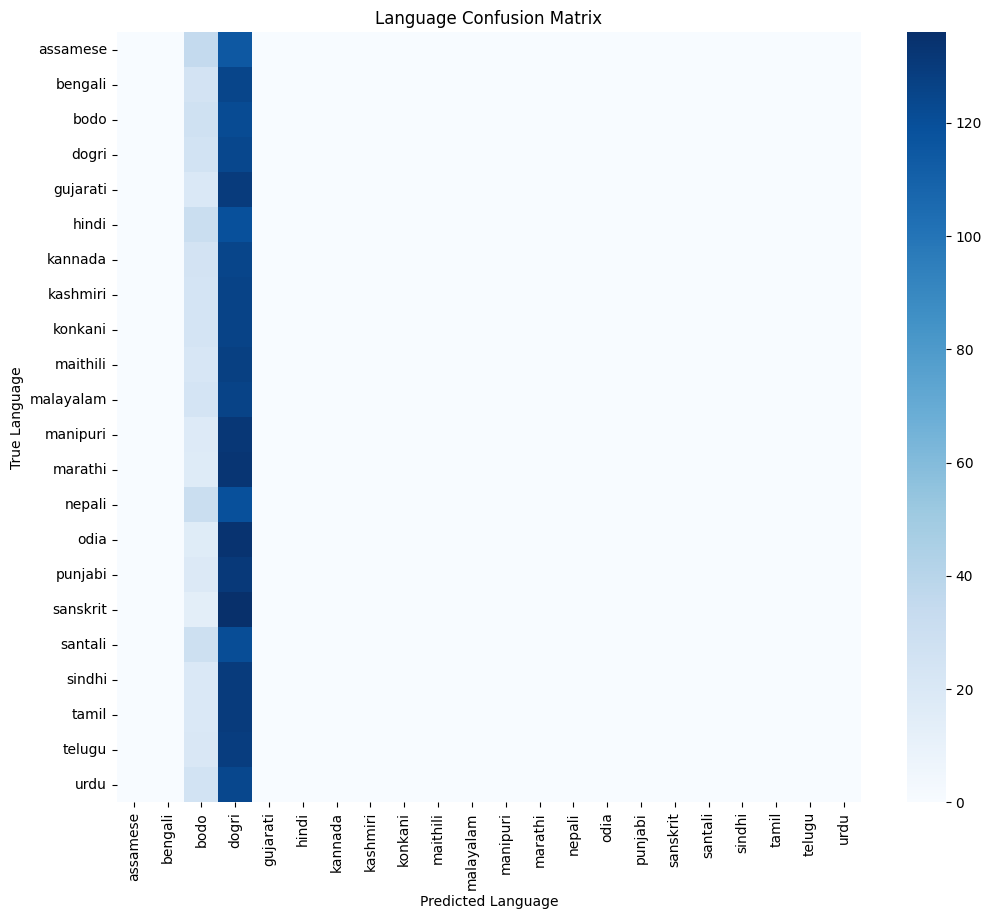

Running t-SNE...


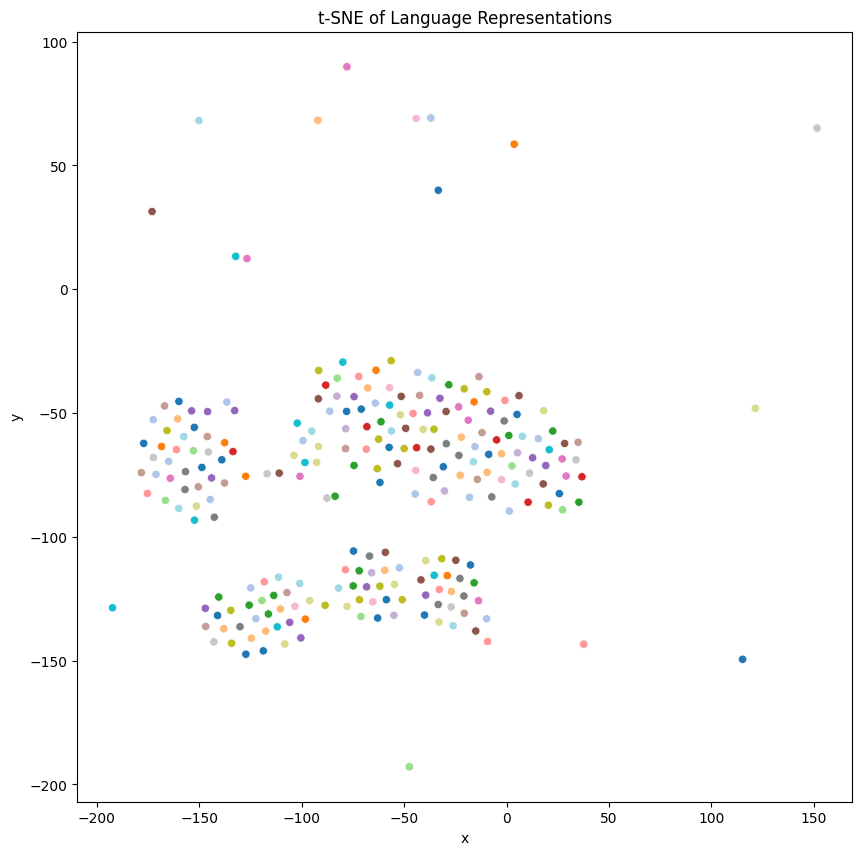


Top language confusions:

true      pred 
sanskrit  dogri    136
odia      dogri    134
marathi   dogri    133
manipuri  dogri    132
punjabi   dogri    131
sindhi    dogri    130
gujarati  dogri    130
tamil     dogri    130
telugu    dogri    129
maithili  dogri    128
Name: count, dtype: int64


In [ ]:
# ==========================================================
# NNTI LANGUAGE IDENTIFICATION PROJECT
# DOMAIN ADVERSARIAL WAV2VEC TRAINING + ANALYSIS
# ==========================================================

!pip install -q transformers datasets torchaudio evaluate seaborn scikit-learn accelerate

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import torchaudio
import seaborn as sns
import matplotlib.pyplot as plt

from datasets import load_dataset, Audio
from transformers import AutoFeatureExtractor, AutoModel
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.manifold import TSNE
from torch.utils.data import DataLoader

# ==========================================================
# DEVICE
# ==========================================================

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.backends.cuda.matmul.allow_tf32 = True

print("Device:", device)

# ==========================================================
# LOAD DATASET (NEW HF API SAFE)
# ==========================================================

dataset = load_dataset("badrex/nnti-dataset-full")

dataset = dataset.cast_column("audio", Audio(sampling_rate=16000))

train_ds = dataset["train"]
val_ds = dataset["validation"]

# ==========================================================
# CREATE LABEL MAPPING
# ==========================================================

languages = sorted(list(set(train_ds["language"])))

label2id = {l:i for i,l in enumerate(languages)}
id2label = {i:l for l,i in label2id.items()}

num_labels = len(languages)

print("Languages:", languages)
print("Total languages:", num_labels)

# ==========================================================
# FEATURE EXTRACTOR
# ==========================================================

feature_extractor = AutoFeatureExtractor.from_pretrained(
    "facebook/mms-300m"
)

# ==========================================================
# AUDIO AUGMENTATION
# ==========================================================

def augment(audio, sr):

    waveform = torch.tensor(audio)

    # noise
    if np.random.rand() < 0.3:
        noise = torch.randn_like(waveform) * 0.003
        waveform += noise

    # speed perturbation
    if np.random.rand() < 0.3:

        speed = np.random.uniform(0.9,1.1)

        waveform = torchaudio.functional.resample(
            waveform.unsqueeze(0),
            sr,
            int(sr*speed)
        ).squeeze(0)

    return waveform.numpy()

# ==========================================================
# PREPROCESS FUNCTION (ROBUST)
# ==========================================================

def preprocess(batch, idx):

    audio_obj = batch.get("audio")

    if audio_obj is None or audio_obj["array"] is None:
        audio = np.zeros(16000)
        sr = 16000
    else:
        audio = audio_obj["array"]
        sr = audio_obj["sampling_rate"]

    # augmentation
    if np.random.rand() < 0.5:
        audio = augment(audio, sr)

    inputs = feature_extractor(
        audio,
        sampling_rate=sr,
        return_tensors="pt"
    )

    speaker_id = idx % 5

    return {
        "input_values": inputs.input_values[0],
        "labels": label2id[batch["language"]],
        "speaker": speaker_id
    }

print("Preprocessing dataset...")
print("Train size:", len(train_ds))
print("Validation size:", len(val_ds))
train_ds = train_ds.map(preprocess, with_indices=True)
val_ds = val_ds.map(preprocess, with_indices=True)


train_ds.set_format(type="torch", columns=["input_values","labels","speaker"])
val_ds.set_format(type="torch", columns=["input_values","labels","speaker"])

# ==========================================================
# COLLATE FUNCTION (PROPER PADDING)
# ==========================================================

def collate_fn(batch):

    input_values = [b["input_values"] for b in batch]

    padded = feature_extractor.pad(
        {"input_values": input_values},
        return_tensors="pt"
    )

    labels = torch.tensor([b["labels"] for b in batch])
    speakers = torch.tensor([b["speaker"] for b in batch])

    padded["labels"] = labels
    padded["speaker"] = speakers

    return padded

# ==========================================================
# GRADIENT REVERSAL
# ==========================================================

class GradientReversal(torch.autograd.Function):

    @staticmethod
    def forward(ctx, x, lambda_):
        ctx.lambda_ = lambda_
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lambda_ * grad_output, None

# ==========================================================
# ADVERSARIAL MODEL
# ==========================================================

class AdversarialWav2Vec(nn.Module):

    def __init__(self, num_languages):

        super().__init__()

        self.encoder = AutoModel.from_pretrained("facebook/mms-300m")

        for param in self.encoder.parameters():
            param.requires_grad = False

        hidden = self.encoder.config.hidden_size

        self.language_head = nn.Linear(hidden, num_languages)

        self.speaker_head = nn.Linear(hidden, 5)

    def forward(self, x, lambda_=0.1):

        outputs = self.encoder(x).last_hidden_state

        pooled = outputs.mean(dim=1)

        language_logits = self.language_head(pooled)

        reversed_features = GradientReversal.apply(pooled, lambda_)

        speaker_logits = self.speaker_head(reversed_features)

        return language_logits, speaker_logits, pooled

model = AdversarialWav2Vec(num_labels).to(device)

# ==========================================================
# OPTIMIZER
# ==========================================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-5,
    weight_decay=0.01
)

ce = nn.CrossEntropyLoss()

# ==========================================================
# DATALOADERS
# ==========================================================

BATCH = 8

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH,
    collate_fn=collate_fn
)

# ==========================================================
# TRAINING
# ==========================================================

EPOCHS = 5

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0

    for batch in train_loader:

        x = batch["input_values"].to(device)
        y = batch["labels"].to(device)
        s = batch["speaker"].to(device)

        lang_logits, speaker_logits, _ = model(x)

        loss_lang = ce(lang_logits, y)
        loss_speaker = ce(speaker_logits, s)

        loss = loss_lang + 0.2 * loss_speaker

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS} Loss:", total_loss/len(train_loader))

# ==========================================================
# EVALUATION
# ==========================================================

model.eval()

preds = []
true = []
embeddings = []

with torch.no_grad():

    for batch in val_loader:

        x = batch["input_values"].to(device)
        y = batch["labels"].cpu().numpy()

        lang_logits, _, emb = model(x)

        pred = torch.argmax(lang_logits,dim=1).cpu().numpy()

        preds.extend(pred)
        true.extend(y)

        embeddings.extend(emb.cpu().numpy())

print("\nClassification Report:\n")

print(classification_report(true,preds,target_names=languages))

# ==========================================================
# CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(true,preds)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=languages,
    yticklabels=languages
)

plt.title("Language Confusion Matrix")
plt.xlabel("Predicted Language")
plt.ylabel("True Language")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.show()

# ==========================================================
# TSNE
# ==========================================================

print("Running t-SNE...")

sample_idx = np.random.choice(len(embeddings), min(1500,len(embeddings)), replace=False)

emb_sample = np.array(embeddings)[sample_idx]
label_sample = np.array(true)[sample_idx]

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

emb2d = tsne.fit_transform(emb_sample)

df = pd.DataFrame()

df["x"] = emb2d[:,0]
df["y"] = emb2d[:,1]
df["label"] = label_sample

plt.figure(figsize=(10,10))

sns.scatterplot(
    x="x",
    y="y",
    hue=[id2label[i] for i in df.label],
    palette="tab20",
    data=df,
    legend=False
)

plt.title("t-SNE of Language Representations")

plt.show()

# ==========================================================
# TOP CONFUSIONS
# ==========================================================

errors = pd.DataFrame({
    "true":[id2label[i] for i in true],
    "pred":[id2label[i] for i in preds]
})

errors = errors[errors.true != errors.pred]

print("\nTop language confusions:\n")

print(errors.value_counts().head(10))